# Statistical Analysis: Prosper Loan Data
### Project 2 — Data and Statistical Reasoning

This notebook analyzes the **Prosper Loan Data** dataset — 113,937 peer-to-peer loan listings from the Prosper lending platform, including borrower demographics, credit risk indicators, and loan performance outcomes.

**Dataset source:** Prosper Loan Data - https://www.kaggle.com/datasets/abdelrhmanragab/prosperloandata/data.


## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Plot styling
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Task 2 — Load Dataset

We load the full Prosper Loan Data CSV and confirm that all columns and data types loaded correctly before doing any further analysis.


In [2]:
df = pd.read_csv('prosperLoanData.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 113937 rows x 81 columns


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [3]:
# Data quality sanity check: flag if the file contains fully-empty padding rows
fully_empty_rows = df.isnull().all(axis=1).sum()
print(f"Fully empty rows: {fully_empty_rows} out of {len(df)}")
print(f"Rows with usable data: {len(df) - fully_empty_rows}")

if fully_empty_rows > 0:
    print("\nWARNING: This file contains fully-empty rows. Dropping them before analysis.")
    df = df.dropna(how='all').reset_index(drop=True)
    print(f"Shape after dropping empty rows: {df.shape}")


Fully empty rows: 0 out of 113937
Rows with usable data: 113937


### Checking: Out-of-range ProsperScore values

In [4]:
# The data dictionary documents `ProsperScore` as ranging from 1-10 (10 = best/lowest risk)
# Check how many records fall outside the documented ProsperScore range (1-10)
out_of_range = df[df['ProsperScore'] > 10]
print(f"Records with ProsperScore > 10: {len(out_of_range)} out of {df['ProsperScore'].notna().sum()} non-null scores")
print(f"Percentage: {len(out_of_range) / df['ProsperScore'].notna().sum() * 100:.3f}%")

Records with ProsperScore > 10: 1456 out of 84853 non-null scores
Percentage: 1.716%


The data shows **1,456 records (1.716% of non-null scores)** with `ProsperScore` = 11, outside the documented range. Since these out-of-range records make up a small share of the data (1.716%), and dropping them entirely avoids introducing an artificial spike at the score-10 boundary (which capping would create), we remove these rows rather than clipping them. This mirrors the same logic Prosper already applies to `DebtToIncomeRatio`, which is capped at 10.01 by design — here, though, we choose removal over capping given how small a share of the data is affected.

In [5]:
# Clean: drop records with out-of-range ProsperScore values
rows_before = len(df)
df = df[~(df['ProsperScore'] > 10)].reset_index(drop=True)
rows_after = len(df)
print(f"\nRows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")
print(f"Max ProsperScore after cleaning: {df['ProsperScore'].max()}")


Rows before: 113937
Rows after:  112481
Rows dropped: 1456
Max ProsperScore after cleaning: 10.0


`ProsperScore` is the platform's custom risk score, with 10 as the documented best/lowest-risk value (1 = highest risk). As discussed above, 1,456 out-of-range records (1.716%) were dropped before further statistics were computed, so the below statistics reflects the cleaned data (and the total row count from here on is slightly reduced from the original load). 

### Cleaning: Duplicate records

Before moving on, we also check for duplicate rows. `ListingKey` is the dataset's unique listing identifier, so any repeated `ListingKey` values would indicate the same loan listing appearing more than once, which would double-count that borrower's data across every statistic, chart, and the hypothesis test. We check both full-row duplicates and `ListingKey` duplicates, and drop any found, keeping the first occurrence.

In [6]:
# Check for duplicate records: full-row duplicates and duplicate ListingKey values
full_dupes = df.duplicated().sum()
key_dupes = df.duplicated(subset=['ListingKey']).sum()
print(f"Full-row duplicates: {full_dupes}")
print(f"Duplicate ListingKey values: {key_dupes}")

# Clean: drop duplicate records, keeping the first occurrence
rows_before = len(df)
df = df.drop_duplicates(subset=['ListingKey'], keep='first').reset_index(drop=True)
rows_after = len(df)
print(f"\nRows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")

Full-row duplicates: 0
Duplicate ListingKey values: 823

Rows before: 112481
Rows after:  111658
Rows dropped: 823


In [7]:
# Confirm data types loaded correctly
df.dtypes.value_counts()


float64    50
object     17
int64      11
bool        3
Name: count, dtype: int64

In [8]:
# Quick look at data types per column (first 20 shown for readability)
df.dtypes.head(20)


ListingKey                    object
ListingNumber                  int64
ListingCreationDate           object
CreditGrade                   object
Term                           int64
LoanStatus                    object
ClosedDate                    object
BorrowerAPR                  float64
BorrowerRate                 float64
LenderYield                  float64
EstimatedEffectiveYield      float64
EstimatedLoss                float64
EstimatedReturn              float64
ProsperRating (numeric)      float64
ProsperRating (Alpha)         object
ProsperScore                 float64
ListingCategory (numeric)      int64
BorrowerState                 object
Occupation                    object
EmploymentStatus              object
dtype: object

**Note:** The clean dataset (after dropping out-of-range `ProsperScore` values and any duplicate listings) is well above the project's minimum requirement of 500 rows and 6 columns, with 81 total columns. It includes numerous numeric variables (e.g. `BorrowerAPR`, `ProsperScore`, `StatedMonthlyIncome`, `DebtToIncomeRatio`) and categorical/grouping variables (e.g. `LoanStatus`, `EmploymentStatus`, `IncomeRange`, `ProsperRating (Alpha)`), satisfying the dataset requirements for this project.

## Task 3 — Descriptive Statistics

We explore summary statistics for key numeric variables, counts of categorical values, and the distribution of variables central to our analytical question (the relationship between `LoanStatus` and `ProsperScore`).


In [9]:
# Summary statistics for key numeric variables
key_numeric_cols = ['ProsperScore', 'BorrowerAPR', 'BorrowerRate', 'StatedMonthlyIncome',
                     'DebtToIncomeRatio', 'EmploymentStatusDuration', 'LoanOriginalAmount']
df[key_numeric_cols].describe()


,ProsperScore,BorrowerAPR,BorrowerRate,StatedMonthlyIncome,DebtToIncomeRatio,EmploymentStatusDuration,LoanOriginalAmount
count,82574.000000,111633.000000,111658.000000,1.116580e+05,103226.000000,104033.000000,111658.000000
mean,5.866350,0.220338,0.194208,5.563576e+03,0.277042,95.878010,8232.054989
std,2.299189,0.079975,0.074469,7.509130e+03,0.557220,94.360574,6164.208384
min,1.000000,0.006530,0.000000,0.000000e+00,0.000000,0.000000,1000.000000
25%,4.000000,0.157840,0.135500,3.166667e+03,0.140000,26.000000,4000.000000
50%,6.000000,0.211560,0.184500,4.589083e+03,0.220000,67.000000,6001.000000
75%,8.000000,0.285440,0.251100,6.710333e+03,0.320000,137.000000,11500.000000
max,10.000000,0.512290,0.497500,1.750003e+06,10.010000,755.000000,35000.000000


**What this reveals:** The mean of ~5.87 sits comfortably mid-range, suggesting most borrowers fall into a moderate-risk band rather than the extremes. `DebtToIncomeRatio` and `StatedMonthlyIncome` both show strong right-skew (large gap between the 75th percentile and the max), indicating a small number of high-income or high-leverage outliers that we'll want to keep in mind when interpreting later visualizations and tests. Notably, `DebtToIncomeRatio`'s observed max of 10.01 is not an organic outlier but a **documented data cap** — per the data dictionary, any ratio above 1000% is returned as 1001% (1000.1%), so values at this ceiling reflect a reporting convention rather than an unusually indebted borrower.

In [10]:
# Counts of categorical values: LoanStatus (our primary feature of interest)
df['LoanStatus'].value_counts()


LoanStatus
Current                   54358
Completed                 38031
Chargedoff                11992
Defaulted                  5017
Past Due (1-15 days)        799
Past Due (31-60 days)       361
Past Due (61-90 days)       310
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      200
Past Due (>120 days)         16
Cancelled                     5
Name: count, dtype: int64

In [11]:
# Counts of categorical values: IncomeRange
df['IncomeRange'].value_counts()


IncomeRange
$25,000-49,999    31817
$50,000-74,999    30402
$100,000+         16561
$75,000-99,999    16476
Not displayed      7741
$1-24,999          7234
Not employed        806
$0                  621
Name: count, dtype: int64

In [12]:
# Counts of categorical values: EmploymentStatus
df['EmploymentStatus'].value_counts()


EmploymentStatus
Employed         65277
Full-time        26340
Self-employed     6013
Not available     5347
Other             3708
Part-time         1088
Not employed       835
Retired            795
Name: count, dtype: int64

**What this reveals:** `LoanStatus` is heavily imbalanced — the large majority of loans are `Current` or `Completed`, with `Defaulted` and `Chargedoff` (our "failed loan" categories of interest) making up a much smaller share. This imbalance is important context for the hypothesis test in Task 5, since our failed-loan sample will be considerably smaller than our completed-loan sample.

In [13]:
# Distribution of ProsperScore (key numeric variable of interest)
df['ProsperScore'].describe()


count    82574.000000
mean         5.866350
std          2.299189
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         10.000000
Name: ProsperScore, dtype: float64

In [14]:
# Missing data check for our variables of interest
cols_of_interest = ['LoanStatus', 'ProsperScore', 'EmploymentStatus',
                     'EmploymentStatusDuration', 'IncomeRange', 'IsBorrowerHomeowner']
df[cols_of_interest].isnull().sum()


LoanStatus                      0
ProsperScore                29084
EmploymentStatus             2255
EmploymentStatusDuration     7625
IncomeRange                     0
IsBorrowerHomeowner             0
dtype: int64

**What this reveals:** `ProsperScore` has a meaningful number of missing values. This is expected — per the data dictionary, `ProsperScore` is only populated for loans originated after July 2009, since it replaced the earlier `CreditGrade` rating system. We'll need to drop these missing values before running our hypothesis test in Task 5, and we note this as a dataset limitation in the written report.

## Task 4 — Visual Models

We create three visual models to explore patterns relevant to our analytical question: **does loan outcome (`LoanStatus`) relate to borrower risk (`ProsperScore`)?**


### Visual Model 1: Bar Chart — Distribution of Loan Status (log scale)

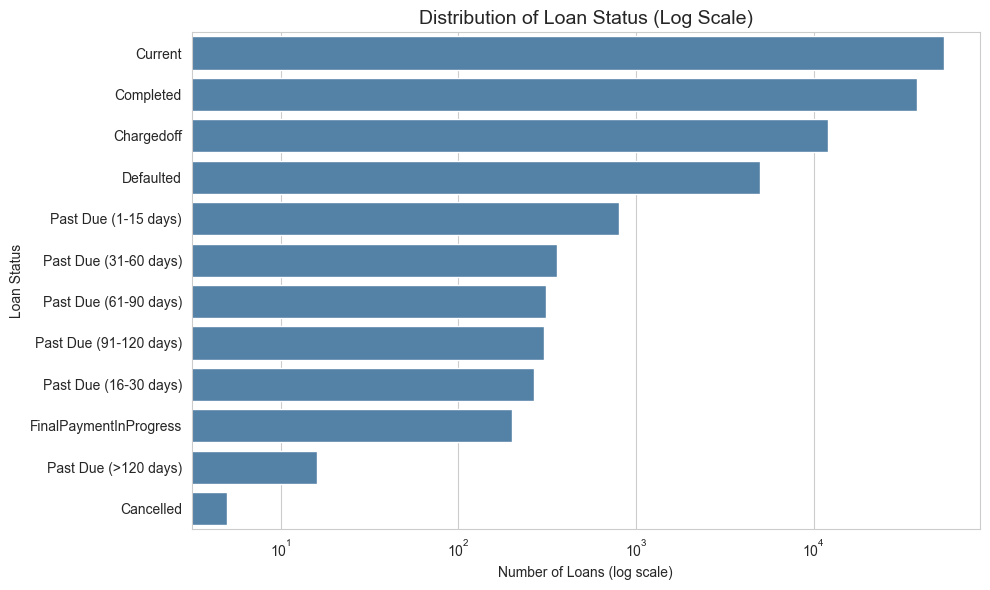

In [15]:
order = df['LoanStatus'].value_counts().index

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, y='LoanStatus', order=order, color='steelblue', ax=ax)
ax.set_xscale('log')
ax.set_title('Distribution of Loan Status (Log Scale)', fontsize=14)
ax.set_xlabel('Number of Loans (log scale)')
ax.set_ylabel('Loan Status')
plt.tight_layout()
plt.show()


**Interpretation:** The log scale is necessary here because `Current` and `Completed` loans vastly outnumber all other categories on a linear scale, which would make rarer statuses like `Defaulted` and `Chargedoff` nearly invisible. The log transformation reveals that non-performing loan categories, while a minority, still represent a substantial "pipeline" of financial distress worth investigating.

### Visual Model 2: Histogram — ProsperScore Distribution by Loan Outcome

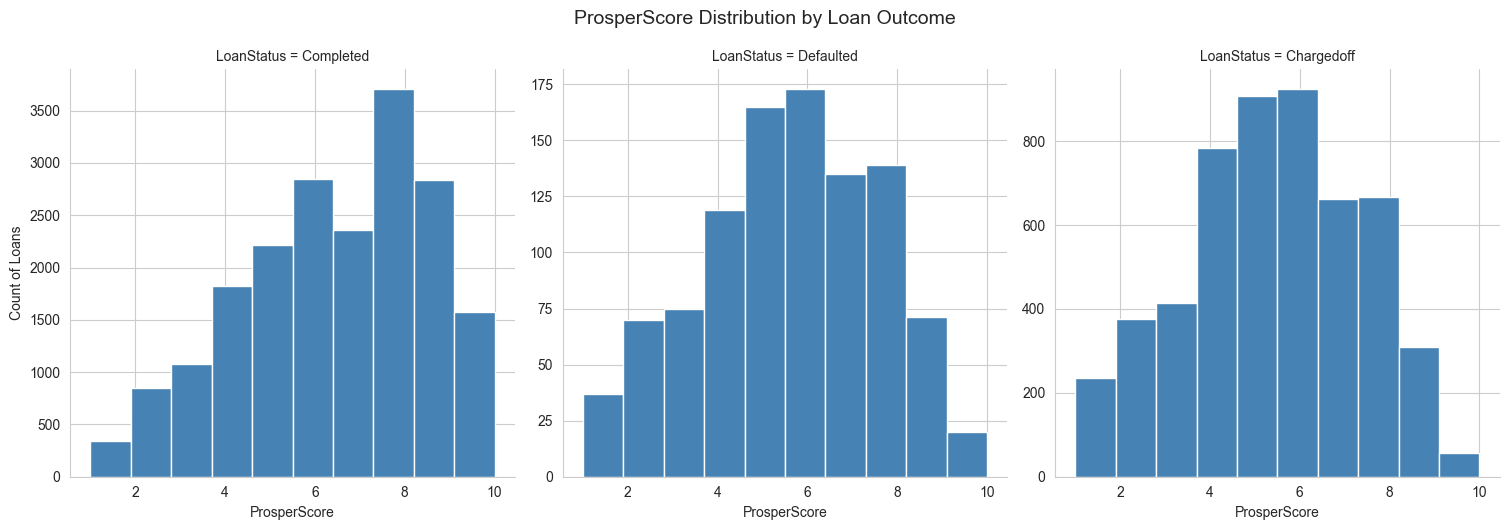

In [16]:
outcomes = ['Completed', 'Defaulted', 'Chargedoff']
df_outcomes = df[df['LoanStatus'].isin(outcomes)]

g = sns.FacetGrid(df_outcomes, col='LoanStatus', col_order=outcomes, height=5, sharey=False)
g.map(plt.hist, 'ProsperScore', bins=10, color='steelblue', edgecolor='white')
g.set_axis_labels('ProsperScore', 'Count of Loans')
g.fig.suptitle('ProsperScore Distribution by Loan Outcome', y=1.05, fontsize=14)
plt.show()


**Interpretation:** `Completed` loans show a clear right-skewed peak around the safer end of the ProsperScore range (around 8), while `Defaulted` and `Chargedoff` loans show a flatter, more symmetrical distribution that extends further into higher-risk territory. This foreshadows a real difference in central tendency between the groups — exactly what we test formally in Task 5.

### Visual Model 3: Correlation Heatmap — Key Numeric Features

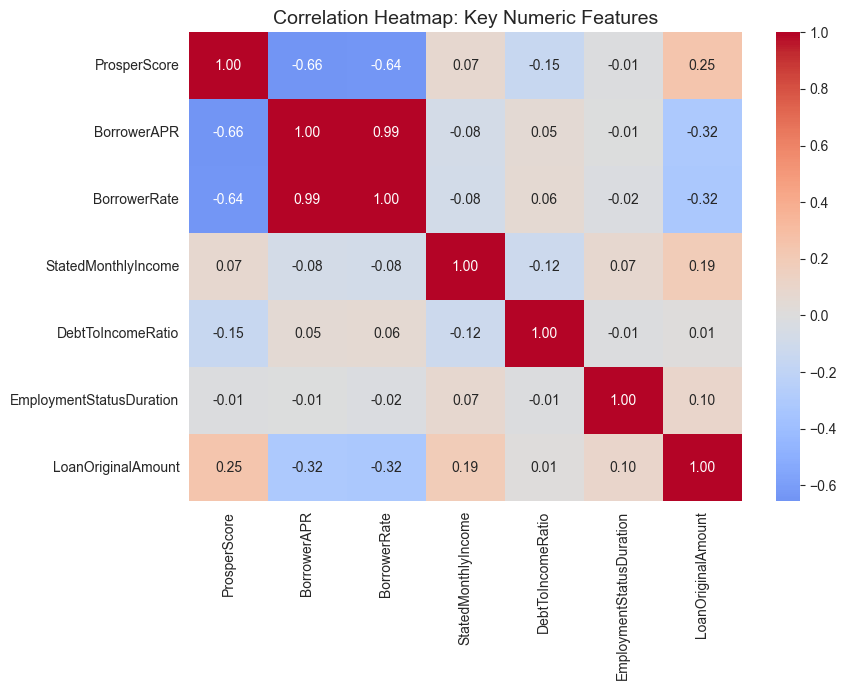

In [17]:
heatmap_cols = ['ProsperScore', 'BorrowerAPR', 'BorrowerRate', 'StatedMonthlyIncome',
                 'DebtToIncomeRatio', 'EmploymentStatusDuration', 'LoanOriginalAmount']

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap: Key Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


**Interpretation:** `ProsperScore` shows a **strong** negative correlation with both `BorrowerAPR` (-0.66) and `BorrowerRate` (-0.64) — lower risk scores correspond to higher interest rates charged, as expected from a risk-based pricing model. Its correlation with `StatedMonthlyIncome` is very weak (0.07), suggesting income alone tells us little about a borrower's assigned risk score.

**Important finding:** `BorrowerAPR` and `BorrowerRate` are near-perfectly correlated with each other (**0.99**) — this is a case of extreme multicollinearity, not an absence of it. The two variables are essentially redundant (APR is derived from the rate plus fees), so they shouldn't both be treated as independent predictors in any further analysis; we note this as a methodological consideration in the written report.

**Comparing the three visual models:** The bar chart is best for understanding the overall *scale and imbalance* of loan outcomes. The faceted histogram best supports our specific analytical question, since it directly visualizes how `ProsperScore` differs across the loan outcomes we care about — this is the visual model most directly relevant to the hypothesis test that follows. The heatmap is most useful for understanding *relationships among the numeric predictors themselves*, helping identify redundant variables (like APR/Rate) and which features are worth focusing on. Together, the three models cover complementary aspects of the dataset: distribution shape, group comparison, and inter-variable relationships.

## Task 5 — Hypothesis Test

**Research question:** Is there a statistically significant difference in mean `ProsperScore` between borrowers whose loans were `Completed` versus those whose loans `Defaulted` or were `Chargedoff`?

- **Null Hypothesis (H₀):** There is no difference in mean ProsperScore between the "Completed" and "Defaulted/Chargedoff" loan groups (μ_completed = μ_failed).
- **Alternative Hypothesis (H₁):** There is a difference in mean ProsperScore between the "Completed" and "Defaulted/Chargedoff" loan groups (μ_completed ≠ μ_failed).

We use a two-tailed independent-samples t-test with α = 0.05.

For this task, we trim the dataset down to the columns most relevant to our investigation (matching the feature set used in prior exploratory work on this dataset).


In [18]:
# Trim dataset to the main interesting and supporting features
df_eda = df[['LoanStatus',
             'ProsperScore',
             'EmploymentStatus',
             'EmploymentStatusDuration',
             'IncomeRange',
             'IsBorrowerHomeowner'
            ]]

df_eda.shape


(111658, 6)

In [19]:
# Filter to the two groups of interest for the hypothesis test and drop missing ProsperScore values
completed = df_eda.loc[df_eda['LoanStatus'] == 'Completed', 'ProsperScore'].dropna()
failed = df_eda.loc[df_eda['LoanStatus'].isin(['Defaulted', 'Chargedoff']), 'ProsperScore'].dropna()

print(f"Completed: n={len(completed)}, mean={completed.mean():.3f}, std={completed.std():.3f}")
print(f"Failed:    n={len(failed)}, mean={failed.mean():.3f}, std={failed.std():.3f}")


Completed: n=19621, mean=6.530, std=2.299
Failed:    n=6340, mean=5.426, std=2.162


In [20]:
# Levene's test for equal variances - informs which t-test variant to use
levene_stat, levene_p = stats.levene(completed, failed)
print(f"Levene's test: statistic={levene_stat:.3f}, p-value={levene_p:.4f}")


Levene's test: statistic=39.411, p-value=0.0000


In [21]:
# Welch's t-test (does not assume equal variances - safer default given unequal group sizes)
t_stat, p_value = stats.ttest_ind(completed, failed, equal_var=False)

# Welch-Satterthwaite degrees of freedom (APA reporting requires this alongside t and p)
v1 = completed.var() / len(completed)
v2 = failed.var() / len(failed)
welch_df = (v1 + v2)**2 / ((v1**2) / (len(completed) - 1) + (v2**2) / (len(failed) - 1))

print(f"Welch's t-test: t-statistic={t_stat:.3f}, df={welch_df:.2f}, p-value={p_value:.6f}")

Welch's t-test: t-statistic=34.801, df=11329.80, p-value=0.000000


In [22]:
# Effect size: Cohen's d (pooled standard deviation)
pooled_sd = np.sqrt(((len(completed) - 1) * completed.std()**2 +
                     (len(failed) - 1) * failed.std()**2) /
                    (len(completed) + len(failed) - 2))
cohens_d = (completed.mean() - failed.mean()) / pooled_sd
print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 0.487


**Result:** With p ≈ 0.000000 (t = 34.801), the difference in mean `ProsperScore` between Completed loans (n = 19,621, mean = 6.530) and Defaulted/Chargedoff loans (n = 6,340, mean = 5.426) is **statistically significant at α = 0.05, and we reject the null hypothesis**. Completed loans have a meaningfully higher average ProsperScore than failed loans.

Levene's test (p < 0.0001) confirmed the two groups have significantly unequal variances, which is why Welch's t-test (not assuming equal variances) was the appropriate choice rather than a standard Student's t-test.

With a sample this large, statistical significance alone is not very informative — it would likely be reached even for a tiny, practically meaningless difference. The effect size, Cohen's d ≈ 0.49, indicates a **medium** effect by conventional thresholds (0.2 = small, 0.5 = medium, 0.8 = large): the two groups' ProsperScore distributions overlap substantially, but the central tendency shift (roughly 1.1 points on a 1–10 scale) is large enough to be practically meaningful, not just statistically detectable.

Full interpretation of this result — including its practical significance for understanding loan risk — is included in the written report (`Statistical_Analysis_Report.pdf`).

## Task 6 — Notebook Summary

In this notebook, I explored the Prosper Loan Data dataset (113,937 loans, 81 features), focusing on the relationship between borrower risk (`ProsperScore`) and loan outcome (`LoanStatus`). Data cleaning removed 1,456 records with out-of-range `ProsperScore` values (>10, outside the documented 1-10 scale) and 823 duplicate `ListingKey` records, leaving 111,658 clean rows. Descriptive statistics revealed a heavily imbalanced outcome distribution, with `Current`/`Completed` loans vastly outnumbering `Defaulted`/`Chargedoff` loans, and a large share of missing `ProsperScore` values tied to a mid-dataset change in Prosper's rating methodology (score only tracked from July 2009 onward). Three visual models — a log-scaled bar chart, a faceted histogram, and a correlation heatmap — showed that completed loans cluster at safer ProsperScores while failed loans show a broader, riskier spread, and also surfaced an unexpected finding: `BorrowerAPR` and `BorrowerRate` are near-perfectly correlated (0.99), meaning they carry essentially redundant information. A Welch's t-test confirmed the visually apparent difference was statistically significant (p < 0.001): completed loans average a ProsperScore of 6.53 versus 5.43 for failed loans, a medium-sized effect (Cohen's d ≈ 0.49). The main challenges encountered were handling missing data introduced by Prosper's 2009 rating-system change, and discovering data-quality issues (out-of-range scores, duplicate listings) that required deliberate cleaning decisions rather than being safe to ignore.